## Importções e leitura dos stats

In [47]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
with open(r"matrix_multiplication\data\stats.json", "r", encoding="utf8") as f:
    data = json.load(f)

In [49]:
records = []
for entry in data:
    for key, value in entry.items():
        value["type"] = key
        records.append(value)

df = pd.DataFrame(records)

In [50]:
# Normalizar colunas ausentes
for col in ["num_cores", "num_servers", "block_size"]:
    if col not in df.columns:
        df[col] = None

df["num_cores"] = df["num_cores"].fillna(df["num_servers"])
df = df.drop(columns=["num_servers"], errors="ignore")

# Ordenar
df = df.sort_values(["type", "block_size", "num_cores"]).reset_index(drop=True)

print("=== TABELA ORIGINAL ===")
print(df[["type", "num_cores", "block_size", "time_seconds"]])

=== TABELA ORIGINAL ===
             type  num_cores  block_size  time_seconds
0   Blocked local          1         128    128.502636
1   Blocked local          2         128     72.352800
2   Blocked local          4         128     42.954266
3   Blocked local          6         128     35.033347
4   Blocked local          8         128     30.545650
5   Blocked local         10         128     29.067674
6   Blocked local         12         128     27.808154
7   Blocked local          1         256    118.307509
8   Blocked local          2         256     72.965026
9   Blocked local          4         256     49.395249
10  Blocked local          6         256     37.935167
11  Blocked local          8         256     31.553169
12  Blocked local         10         256     28.631263
13  Blocked local         12         256     30.043067
14  Blocked local          1         512    112.326914
15  Blocked local          2         512     95.600444
16  Blocked local          4         512 

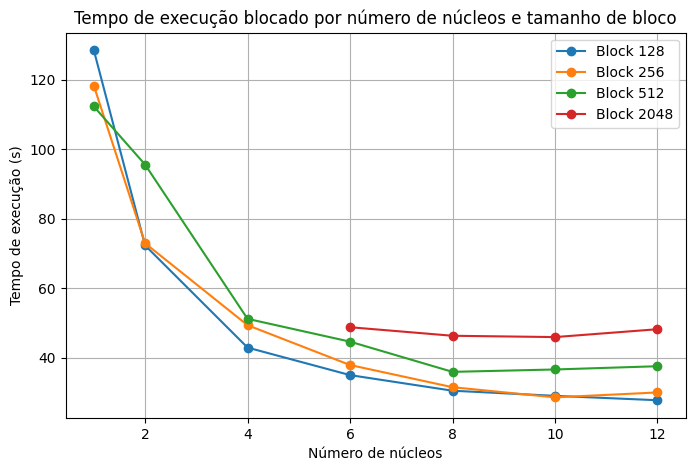

In [51]:
df_blocked = df[df['type'] != 'Linear'].copy()

plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo de execução (s)")
plt.title("Tempo de execução blocado por número de núcleos e tamanho de bloco")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t1_linear = df.loc[df["type"] == "Linear", "time_seconds"].values[0]
t1_blocked128 = df.loc[
    (df["type"] == "Blocked local") & (df["block_size"] == 128) & (df["num_cores"] == 1),
    "time_seconds",
].values[0]

df_blocked128 = df[
    (df["type"] == "Blocked local") &
    (df["block_size"] == 128)
].copy()

In [ ]:
def compute_metrics(df, base_time):
    df = df.copy()
    df["speedup"] = base_time / df["time_seconds"]
    df["efficiency"] = df["speedup"] / df["num_cores"]
    df["redundancy"] = (df["time_seconds"] * df["num_cores"]) / base_time
    return df


In [65]:
df_linear_base = compute_metrics(df, t1_linear)
df_blocked128 = compute_metrics(df, t1_blocked128)

In [60]:
def summary_table(df, label):
    print(f"\n=== MÉTRICAS USANDO BASE: {label} ===")
    print(
        df[["type", "num_cores", "block_size", "time_seconds", "speedup", "efficiency", "redundancy"]]
        .round(3)
        .to_string(index=False)
    )

In [61]:
summary_table(df_linear_base, "Linear")


=== MÉTRICAS USANDO BASE: Linear ===
         type  num_cores  block_size  time_seconds  speedup  efficiency  redundancy
Blocked local          1         128       128.503    5.751       5.751       0.174
Blocked local          2         128        72.353   10.214       5.107       0.196
Blocked local          4         128        42.954   17.205       4.301       0.232
Blocked local          6         128        35.033   21.095       3.516       0.284
Blocked local          8         128        30.546   24.194       3.024       0.331
Blocked local         10         128        29.068   25.424       2.542       0.393
Blocked local         12         128        27.808   26.576       2.215       0.452
Blocked local          1         256       118.308    6.247       6.247       0.160
Blocked local          2         256        72.965   10.128       5.064       0.197
Blocked local          4         256        49.395   14.961       3.740       0.267
Blocked local          6         256  

In [62]:
summary_table(df_blocked128, "Blocked local 128")


=== MÉTRICAS USANDO BASE: Blocked local 128 ===
         type  num_cores  block_size  time_seconds  speedup  efficiency  redundancy
Blocked local          1         128       128.503    1.000       1.000       1.000
Blocked local          2         128        72.353    1.776       0.888       1.126
Blocked local          4         128        42.954    2.992       0.748       1.337
Blocked local          6         128        35.033    3.668       0.611       1.636
Blocked local          8         128        30.546    4.207       0.526       1.902
Blocked local         10         128        29.068    4.421       0.442       2.262
Blocked local         12         128        27.808    4.621       0.385       2.597
Blocked local          1         256       118.308    1.086       1.086       0.921
Blocked local          2         256        72.965    1.761       0.881       1.136
Blocked local          4         256        49.395    2.602       0.650       1.538
Blocked local          6   

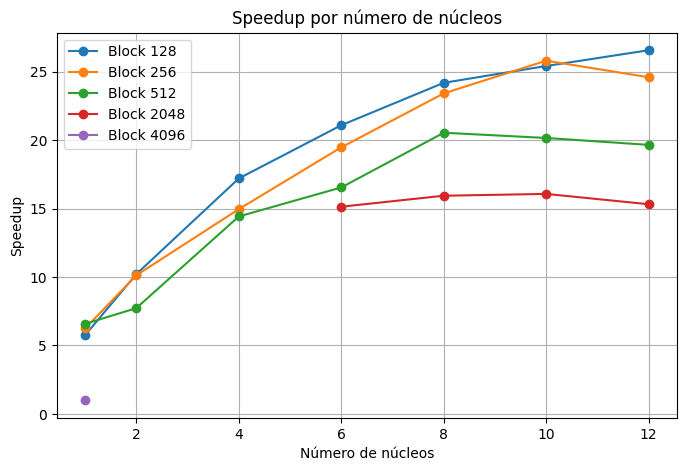

In [71]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_linear_base.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()

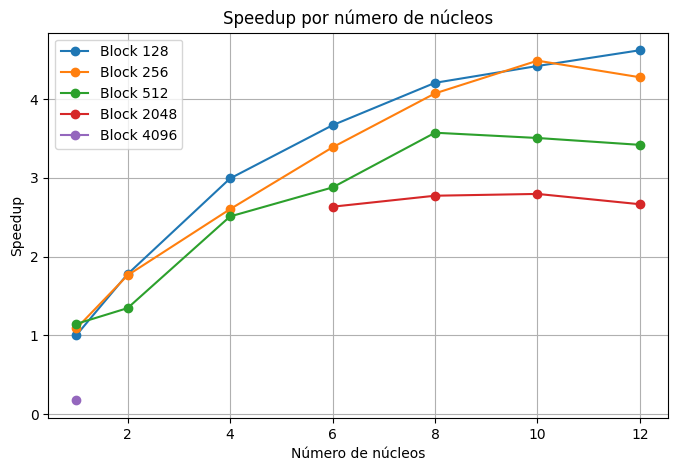

In [ ]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked128.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()

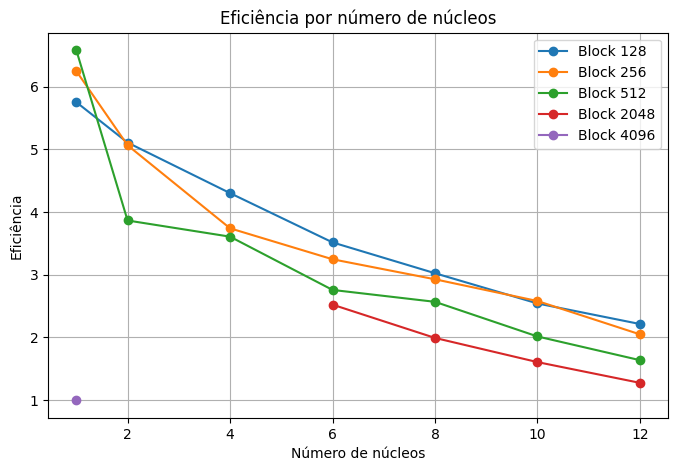

In [74]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_linear_base.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


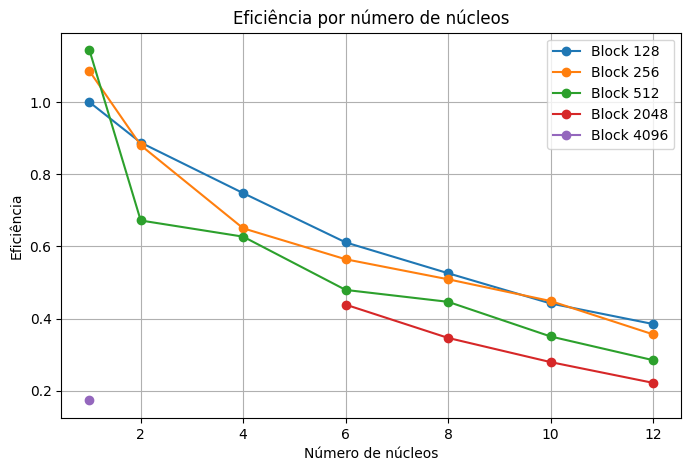

In [76]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked128.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()

## Gráficos Comparativos

#### Grafíco das execuções paralelas locais usando o algoritmo de multiplicação de blocos

In [51]:
# Filtrar apenas execuções "Blocked local"
df_blocked = df[df['type'] == 'Blocked local'].copy()

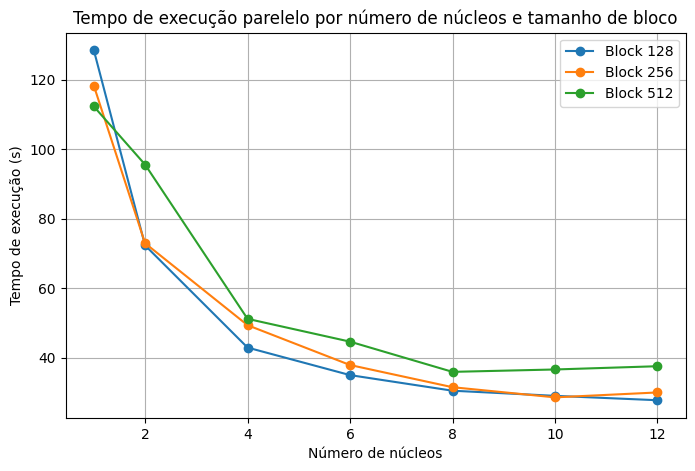

In [52]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo de execução (s)")
plt.title("Tempo de execução parelelo por número de núcleos e tamanho de bloco")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
# Tempo linear (base)
T1 = df[df['type'] == 'Linear']['time_seconds'].iloc[0]
T2 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 128)]['time_seconds'].iloc[0]
T3 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 256)]['time_seconds'].iloc[0]
T4 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 512)]['time_seconds'].iloc[0]

print(T1)
print(T2)

# Calcular speedup e eficiência
df_blocked["speedup"] = T2 / df_blocked["time_seconds"]
df_blocked["efficiency"] = df_blocked["speedup"] / df_blocked["num_cores"]

df_blocked

739.0162164000212
128.50263569998788


,time_seconds,num_cores,block_size,type,speedup,efficiency
1,128.502636,1,128,Blocked local,1.000000,1.000000
2,72.352800,2,128,Blocked local,1.776056,0.888028
3,42.954266,4,128,Blocked local,2.991615,0.747904
4,35.033347,6,128,Blocked local,3.668009,0.611335
5,30.545650,8,128,Blocked local,4.206905,0.525863
6,29.067674,10,128,Blocked local,4.420809,0.442081
7,27.808154,12,128,Blocked local,4.621042,0.385087
8,118.307509,1,256,Blocked local,1.086175,1.086175
9,72.965026,2,256,Blocked local,1.761154,0.880577
10,49.395249,4,256,Blocked local,2.601518,0.650380


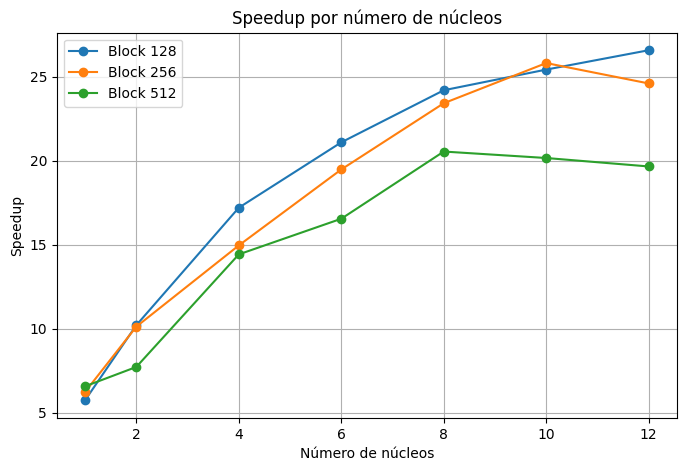

In [47]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


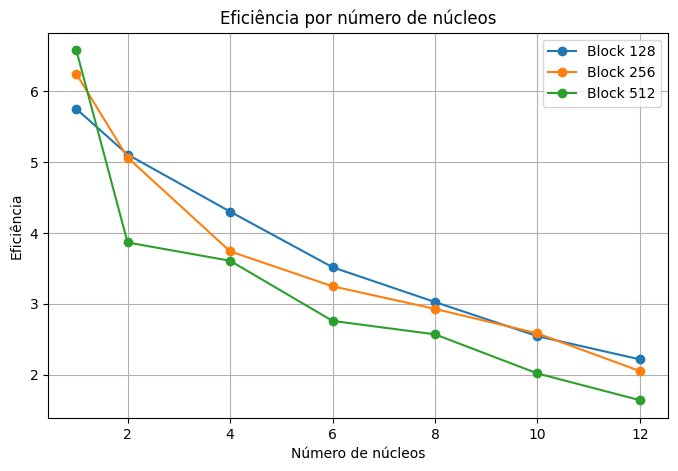

In [48]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


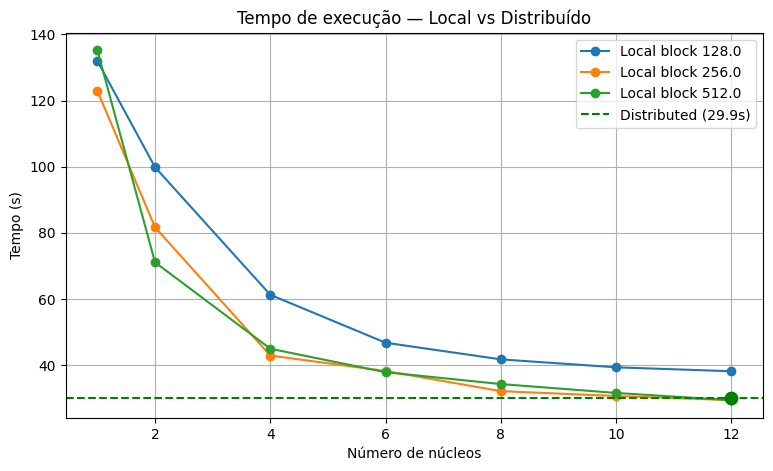

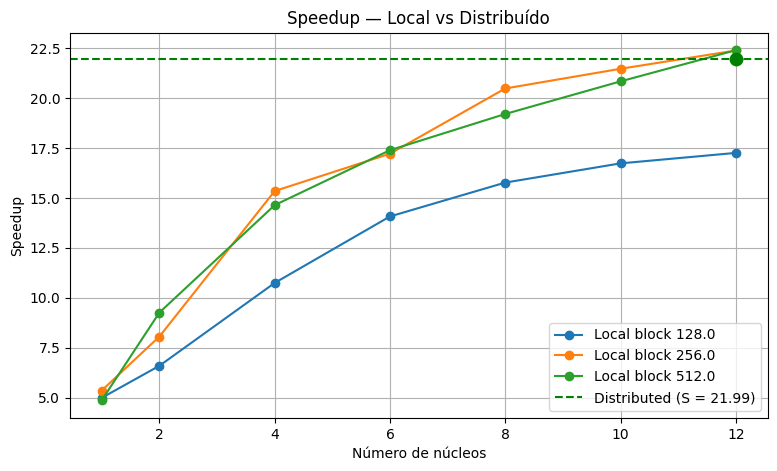

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Ler os dados ===
with open(r"matrix_multiplication\data\stats.json", "r") as f:
    data = json.load(f)

records = []
for entry in data:
    for key, value in entry.items():
        value["type"] = key
        records.append(value)

df = pd.DataFrame(records)

# === 2️⃣ Extrair tempos relevantes ===
T_linear = df.loc[df['type'] == 'Linear', 'time_seconds'].iloc[0]
T_distributed = df.loc[df['type'] == 'Distributed', 'time_seconds'].iloc[0]

# Filtrar execuções locais bloqueadas
df_blocked = df[df['type'] == 'Blocked local'].copy()

# Calcular speedup e eficiência relativos ao linear
df_blocked["speedup"] = T_linear / df_blocked["time_seconds"]
df_blocked["efficiency"] = df_blocked["speedup"] / df_blocked["num_cores"]

# === 3️⃣ Criar DataFrame com linha do distribuído ===
distributed_row = pd.DataFrame([{
    "type": "Distributed",
    "time_seconds": T_distributed,
    "num_cores": df_blocked["num_cores"].max(),  # ou outro valor simbólico (ex: 12)
    "block_size": 2048,
    "speedup": T_linear / T_distributed,
    "efficiency": (T_linear / T_distributed) / df_blocked["num_cores"].max()
}])

# Juntar tudo
df_all = pd.concat([df_blocked, distributed_row], ignore_index=True)

# === 4️⃣ Gráfico 1: Tempo comparando local e distribuído ===
plt.figure(figsize=(9,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Local block {block_size}")

plt.axhline(T_distributed, color="green", linestyle="--", label=f"Distributed ({T_distributed:.1f}s)")
plt.scatter([12], [T_distributed], color="green", s=80, zorder=5)

plt.title("Tempo de execução — Local vs Distribuído")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo (s)")
plt.legend()
plt.grid(True)
plt.show()

# === 5️⃣ Gráfico 2: Speedup comparando local e distribuído ===
plt.figure(figsize=(9,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Local block {block_size}")

plt.axhline(T_linear / T_distributed, color="green", linestyle="--", label=f"Distributed (S = {T_linear / T_distributed:.2f})")
plt.scatter([12], [T_linear / T_distributed], color="green", s=80, zorder=5)

plt.title("Speedup — Local vs Distribuído")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)
plt.show()


## Cálculo do Speedup

## Cálculo da Eficiência

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bruno\AppData\Local\Temp\ipykernel_19228\1628863117.py:8: SyntaxWarning: invalid escape sequence '\d'
  with open("matrix_multiplication\data\stats.json", "r") as f:


=== TABELA ORIGINAL ===
             type  num_cores  block_size  time_seconds
0   Blocked local        1.0         128    128.502636
1   Blocked local        2.0         128     72.352800
2   Blocked local        4.0         128     42.954266
3   Blocked local        6.0         128     35.033347
4   Blocked local        8.0         128     30.545650
5   Blocked local       10.0         128     29.067674
6   Blocked local       12.0         128     27.808154
7   Blocked local        1.0         256    118.307509
8   Blocked local        2.0         256     72.965026
9   Blocked local        4.0         256     49.395249
10  Blocked local        6.0         256     37.935167
11  Blocked local        8.0         256     31.553169
12  Blocked local       10.0         256     28.631263
13  Blocked local       12.0         256     30.043067
14  Blocked local        1.0         512    112.326914
15  Blocked local        2.0         512     95.600444
16  Blocked local        4.0         512 

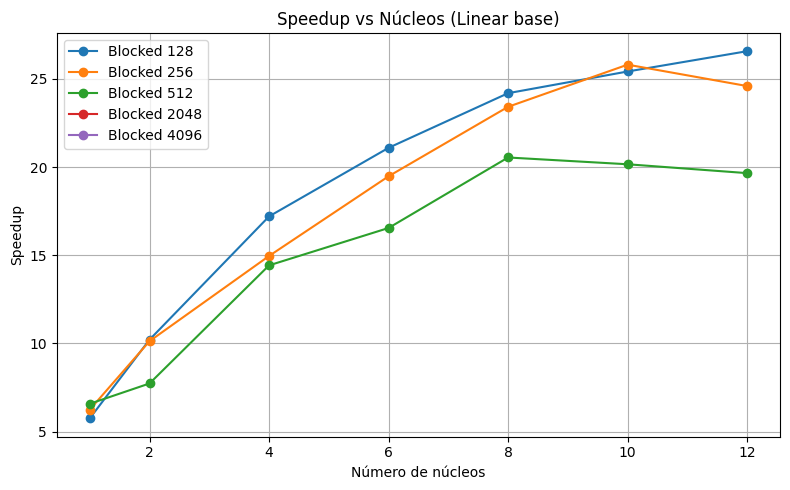

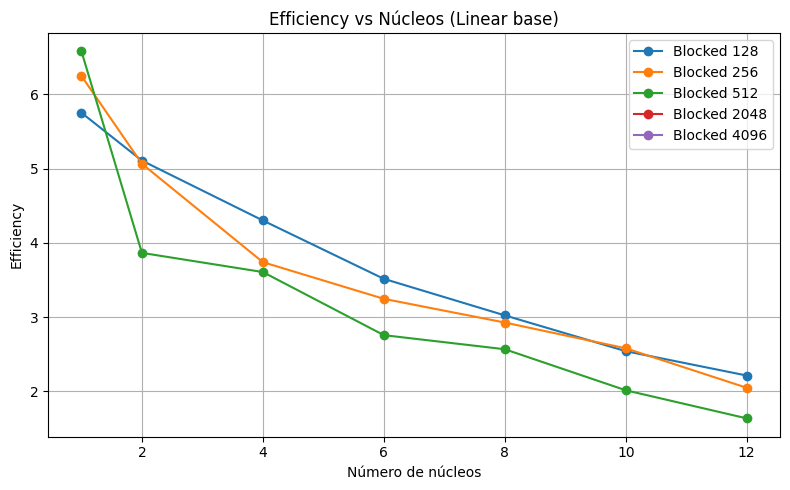

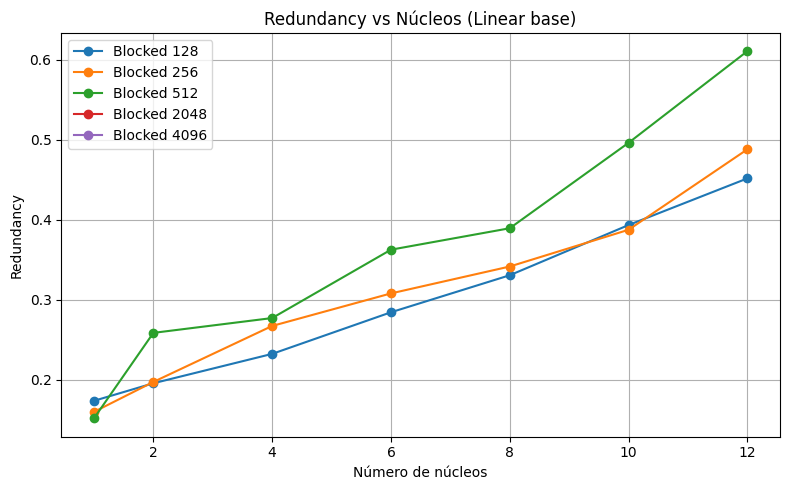

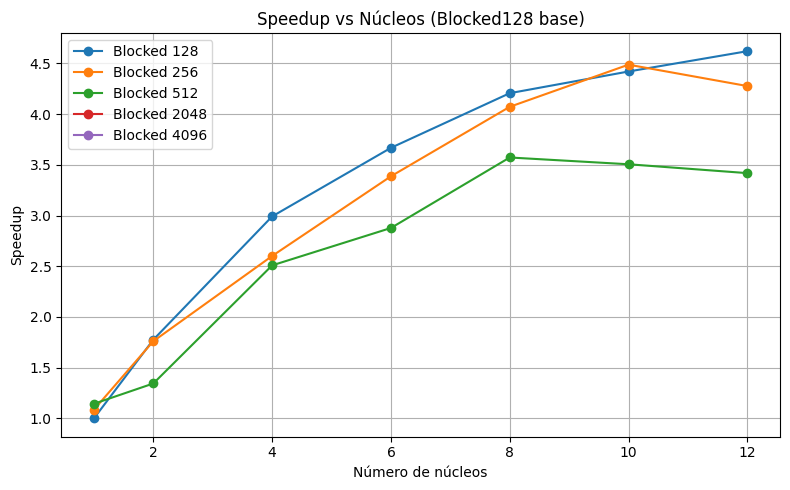

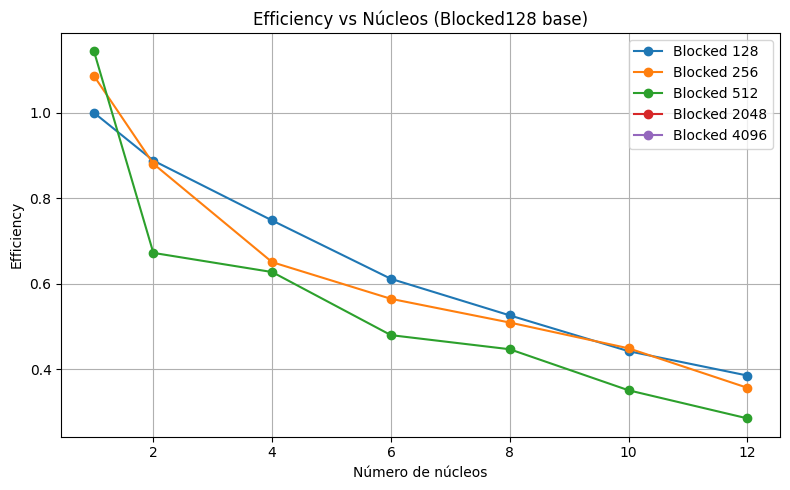

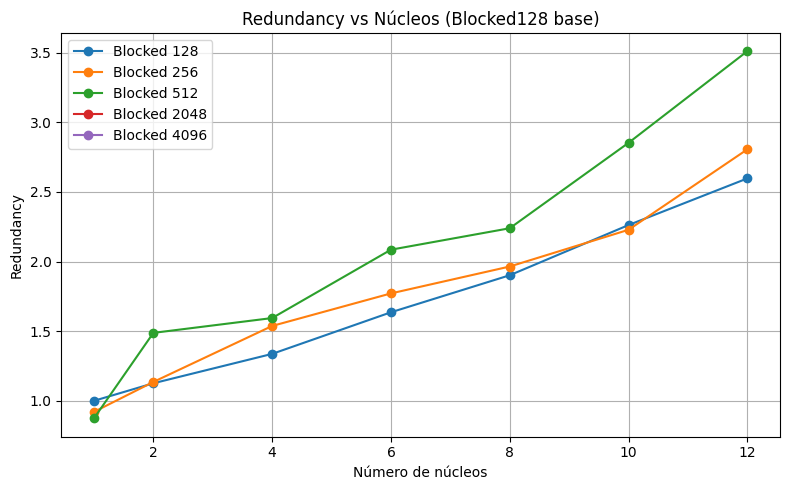

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------
# 1. Ler o arquivo JSON
# -------------------------------------
with open("matrix_multiplication\data\stats.json", "r") as f:
    data = json.load(f)

# -------------------------------------
# 2. Normalizar em um DataFrame
# -------------------------------------
records = []
for entry in data:
    for key, val in entry.items():
        record = val.copy()
        record["type"] = key
        records.append(record)

df = pd.DataFrame(records)

# Normalizar colunas ausentes
for col in ["num_cores", "num_servers", "block_size"]:
    if col not in df.columns:
        df[col] = None

df["num_cores"] = df["num_cores"].fillna(df["num_servers"])
df = df.drop(columns=["num_servers"], errors="ignore")

# Ordenar
df = df.sort_values(["type", "block_size", "num_cores"]).reset_index(drop=True)

print("=== TABELA ORIGINAL ===")
print(df[["type", "num_cores", "block_size", "time_seconds"]])

# -------------------------------------
# 3. Identificar casos base
# -------------------------------------
t1_linear = df.loc[df["type"] == "Linear", "time_seconds"].values[0]
t1_blocked128 = df.loc[
    (df["type"] == "Blocked local") & (df["block_size"] == 128) & (df["num_cores"] == 1),
    "time_seconds",
].values[0]

# -------------------------------------
# 4. Calcular speedup, eficiência e redundância
# -------------------------------------
def compute_metrics(df, base_time):
    df = df.copy()
    df["speedup"] = base_time / df["time_seconds"]
    df["efficiency"] = df["speedup"] / df["num_cores"]
    df["redundancy"] = (df["time_seconds"] * df["num_cores"]) / base_time
    return df

df_linear_base = compute_metrics(df, t1_linear)
df_block128_base = compute_metrics(df, t1_blocked128)

# -------------------------------------
# 5. Mostrar tabelas resumidas
# -------------------------------------
def summary_table(df, label):
    print(f"\n=== MÉTRICAS USANDO BASE: {label} ===")
    print(
        df[["type", "num_cores", "block_size", "time_seconds", "speedup", "efficiency", "redundancy"]]
        .round(3)
        .to_string(index=False)
    )

summary_table(df_linear_base, "Linear")
summary_table(df_block128_base, "Blocked local 128")

# -------------------------------------
# 6. Gráficos comparativos
# -------------------------------------
def plot_metric(df, metric, base_label):
    plt.figure(figsize=(8, 5))
    for bsize in sorted(df["block_size"].dropna().unique()):
        subset = df[(df["type"] == "Blocked local") & (df["block_size"] == bsize)]
        plt.plot(subset["num_cores"], subset[metric], marker="o", label=f"Blocked {int(bsize)}")
    plt.title(f"{metric.capitalize()} vs Núcleos ({base_label})")
    plt.xlabel("Número de núcleos")
    plt.ylabel(metric.capitalize())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{metric}_{base_label.replace(' ', '_')}.png", dpi=150)
    plt.show()

plot_metric(df_linear_base, "speedup", "Linear base")
plot_metric(df_linear_base, "efficiency", "Linear base")
plot_metric(df_linear_base, "redundancy", "Linear base")

plot_metric(df_block128_base, "speedup", "Blocked128 base")
plot_metric(df_block128_base, "efficiency", "Blocked128 base")
plot_metric(df_block128_base, "redundancy", "Blocked128 base")
